# Fiting Models to Environmental Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Regression Models

In [2]:
from scipy import stats

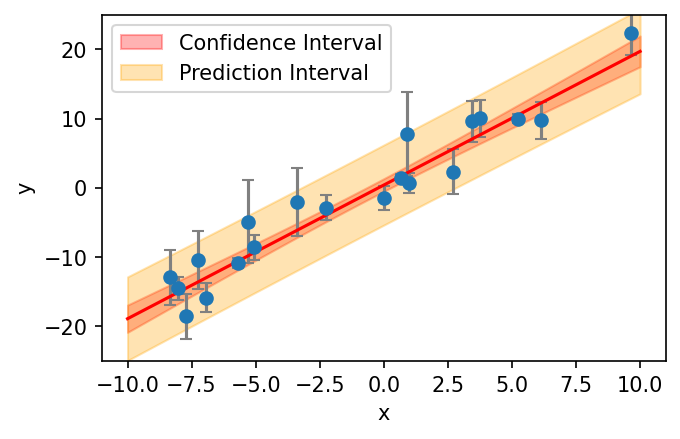

In [3]:
N = 20

np.random.seed(19)

x = np.random.uniform(-10, 10, N)
y = 2 * x

err = np.random.normal(0, 3, N)

y += err
y_err = np.abs(err) + np.random.normal(0.2, 0.05, N)

x_err = np.random.normal(1, 0.2, N)

# plt.scatter(x, y, zorder=3)
plt.errorbar(x, y, yerr=y_err, fmt='o', ecolor='gray', capsize=3)
# plt.errorbar(x, y, yerr=y_err, xerr=x_err, fmt='o', ecolor='gray', capsize=3)

plt.xlim(-11, 11)
plt.ylim(-25, 25)

plt.xlabel('x')
plt.ylabel('y')

# p, cov = np.polyfit(x, y, 1, cov=True)
p, cov = np.polyfit(x, y, 1, w=1/(y_err**0.5), cov=True)

y_fitted = np.polyval(p, x)
residuals = y - y_fitted
mse = np.var(residuals, ddof=2)  # Mean squared error (with degrees of freedom correction)

nx = np.linspace(-10, 10, 100)

pred = np.polyval(p, nx)
plt.plot(nx, pred, color='red')

pred_var = np.diag(np.dot(np.dot(np.vander(nx, 2), cov), np.vander(nx, 2).T))
pred_std = np.sqrt(pred_var)
plt.fill_between(nx, pred - 1.96 * pred_std, pred + 1.96 * pred_std, color='red', alpha=0.3, label='Confidence Interval')

pred_var_prediction = pred_var + mse
pred_std_prediction = np.sqrt(pred_var_prediction)
plt.fill_between(nx, pred - 1.96 * pred_std_prediction, pred + 1.96 * pred_std_prediction, color='orange', alpha=0.3, label='Prediction Interval')

plt.legend()


([], [])

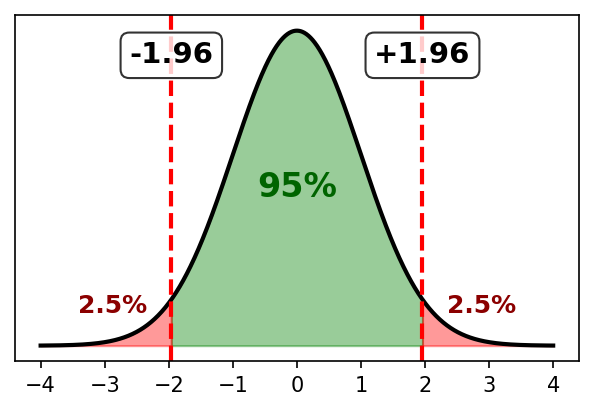

In [4]:
# Single plot showing why 95% CI uses 1.96
from scipy import stats

fig, ax = plt.subplots()

# Standard normal distribution
z = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(z, 0, 1)
ax.plot(z, pdf, 'k-', linewidth=2, label='Standard Normal N(0,1)')

# Shade the 95% region (between -1.96 and +1.96)
z_95 = np.linspace(-1.96, 1.96, 200)
pdf_95 = stats.norm.pdf(z_95, 0, 1)
ax.fill_between(z_95, pdf_95, alpha=0.4, color='green', label='95% of area (0.95)')

# Shade the left tail (2.5%)
z_left = np.linspace(-4, -1.96, 100)
pdf_left = stats.norm.pdf(z_left, 0, 1)
ax.fill_between(z_left, pdf_left, alpha=0.4, color='red', label='2.5% in each tail')

# Shade the right tail (2.5%)
z_right = np.linspace(1.96, 4, 100)
pdf_right = stats.norm.pdf(z_right, 0, 1)
ax.fill_between(z_right, pdf_right, alpha=0.4, color='red')

# Mark the critical values
ax.axvline(-1.96, color='red', linestyle='--', linewidth=2)
ax.axvline(1.96, color='red', linestyle='--', linewidth=2)

# Add labels
ax.text(-1.96, 0.35, '-1.96', ha='center', va='bottom', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(1.96, 0.35, '+1.96', ha='center', va='bottom', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(0, 0.2, '95%', ha='center', va='center', fontsize=16, fontweight='bold', color='darkgreen')
ax.text(-2.88, 0.05, '2.5%', ha='center', va='center', fontsize=12, fontweight='bold', color='darkred')
ax.text(2.88, 0.05, '2.5%', ha='center', va='center', fontsize=12, fontweight='bold', color='darkred')

plt.yticks([])

Text(0, 0.5, 'y')

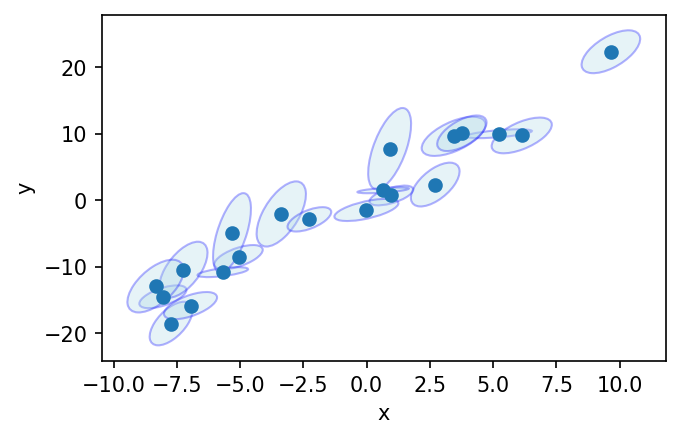

In [5]:
from matplotlib.patches import Ellipse

def plot_error_ellipse(x, y, xerr, yerr, correlation=0.0, ax=None, **kwargs):
    """Plot error ellipses for correlated x,y errors"""
    if ax is None:
        ax = plt.gca()
    
    for i in range(len(x)):
        # Covariance matrix
        cov = np.array([[xerr[i]**2, correlation * xerr[i] * yerr[i]],
                       [correlation * xerr[i] * yerr[i], yerr[i]**2]])
        
        # Eigenvalues and eigenvectors
        eigenvals, eigenvecs = np.linalg.eig(cov)
        angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
        
        # 1-sigma ellipse
        width = 2 * np.sqrt(eigenvals[0])
        height = 2 * np.sqrt(eigenvals[1])
        
        ellipse = Ellipse((x[i], y[i]), width, height, angle=angle, **kwargs)
        ax.add_patch(ellipse)

# Usage:
fig, ax = plt.subplots()
ax.scatter(x, y, zorder=5)
plot_error_ellipse(x, y, x_err, y_err, correlation=0.6, 
                  alpha=0.3, facecolor='lightblue', edgecolor='blue')

plt.xlabel('x')
plt.ylabel('y')


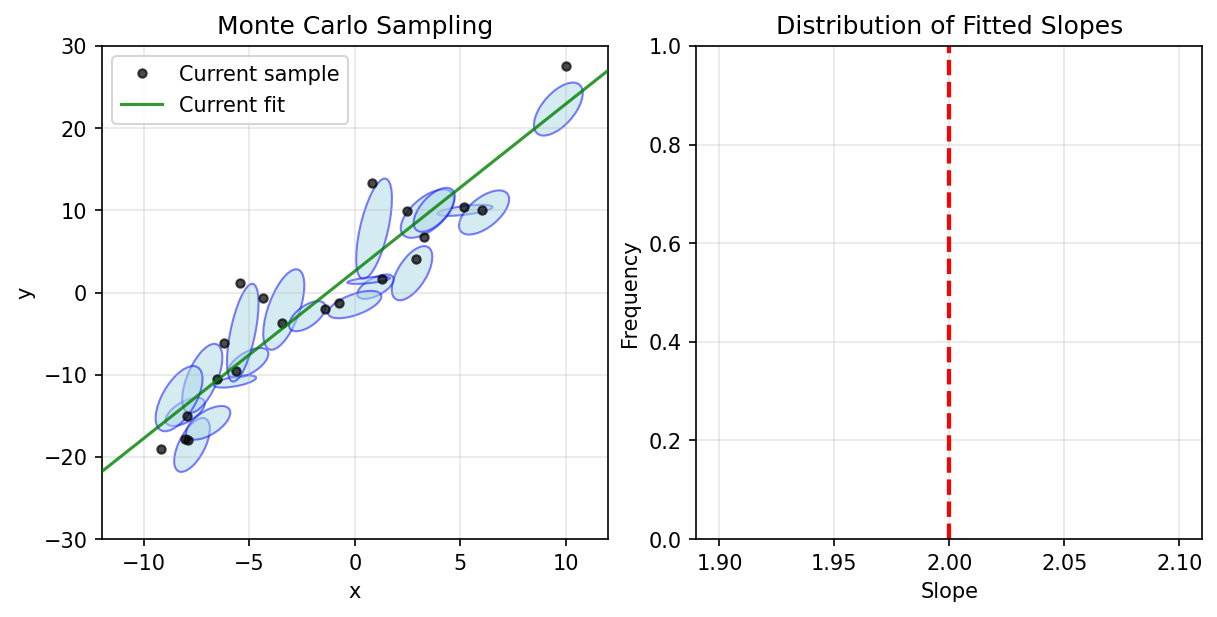

In [7]:
# Monte Carlo animation through error ellipses
import matplotlib.animation as animation

# Set up the data with correlated errors
np.random.seed(19)
correlation = 0.6

# Store all Monte Carlo results
n_iterations = 200
slopes = []
intercepts = []
all_x_samples = []
all_y_samples = []

# Pre-generate all samples for animation
for i in range(n_iterations):
    # Sample from error ellipses
    x_sample = np.zeros(N)
    y_sample = np.zeros(N)
    
    for j in range(N):
        # Individual point covariance
        point_cov = np.array([[x_err[j]**2, correlation * x_err[j] * y_err[j]],
                             [correlation * x_err[j] * y_err[j], y_err[j]**2]])
        
        # Sample from this point's error ellipse
        sample = np.random.multivariate_normal([x[j], y[j]], point_cov)
        x_sample[j] = sample[0]
        y_sample[j] = sample[1]
    
    # Fit line to this sample
    p_sample = np.polyfit(x_sample, y_sample, 1)
    slopes.append(p_sample[0])
    intercepts.append(p_sample[1])
    all_x_samples.append(x_sample.copy())
    all_y_samples.append(y_sample.copy())

# Create the animation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

# Set up the main plot
ax1.set_xlim(-12, 12)
ax1.set_ylim(-30, 30)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Monte Carlo Sampling')
ax1.grid(True, alpha=0.3)

# Plot original data and error ellipses
# ax1.scatter(x, y, zorder=10, label='True data')
plot_error_ellipse(x, y, x_err, y_err, correlation=correlation, ax=ax1,
                  alpha=0.5, facecolor='lightblue', edgecolor='blue')

# Set up histogram plot
ax2.set_xlabel('Slope')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Fitted Slopes')
ax2.grid(True, alpha=0.3)
ax2.axvline(2.0, color='red', linestyle='--', linewidth=2, label='True slope')

# Animation elements
current_points, = ax1.plot([], [], 'ko', markersize=4, alpha=0.7, label='Current sample', zorder=99)
current_line, = ax1.plot([], [], 'g-', linewidth=1.5, alpha=0.8, label='Current fit', zorder=99)
family_lines = []  # Will store previous fits

def animate(frame):
    # Clear previous current sample and line
    current_points.set_data([], [])
    current_line.set_data([], [])
    
    # Remove old family lines
    for line in family_lines:
        line.remove()
    family_lines.clear()
    
    if frame < len(all_x_samples):
        # Get current sample
        x_curr = all_x_samples[frame]
        y_curr = all_y_samples[frame]
        slope_curr = slopes[frame]
        intercept_curr = intercepts[frame]
        
        # Update current sample points
        current_points.set_data(x_curr, y_curr)
        
        # Update current fit line
        x_line = np.linspace(-12, 12, 100)
        y_line = intercept_curr + slope_curr * x_line
        current_line.set_data(x_line, y_line)
        
        # Only show last 50 lines for performance
        start_idx = max(0, frame - 50)
        for i in range(start_idx, frame):
            # Calculate alpha based on recency
            recency = (i - start_idx) / max(1, frame - start_idx)
            alpha = 0.1 + 0.4 * recency  # Fade from 0.1 to 0.5
            
            # Plot this historical line
            y_hist = intercepts[i] + slopes[i] * x_line
            line, = ax1.plot(x_line, y_hist, 'gray', linewidth=0.5, alpha=alpha, zorder=1)
            family_lines.append(line)
        
        # Update histogram (same as before)
        if frame > 10:
            ax2.clear()
            ax2.hist(slopes[:frame], bins=20, alpha=0.7, color='lightgreen', 
                    density=True, label=f'n={frame}')
            ax2.axvline(2.0, color='red', linestyle='--', linewidth=2, label='True slope')
            ax2.axvline(np.mean(slopes[:frame]), color='blue', linestyle='-', 
                       linewidth=2, label=f'Mean: {np.mean(slopes[:frame]):.2f}')
            ax2.set_xlabel('Slope')
            ax2.set_ylabel('Density')
            ax2.set_title(f'Distribution of Fitted Slopes (n={frame})')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
    
    return current_points, current_line

# Create and run animation
ax1.legend()
ani = animation.FuncAnimation(fig, animate, frames=n_iterations, 
                            interval=100, blit=False, repeat=True)

# To save the animation (uncomment if needed):
# ani.save('figs/monte_carlo_regression.gif', writer='pillow', fps=10, dpi=100)

In [8]:
import corner

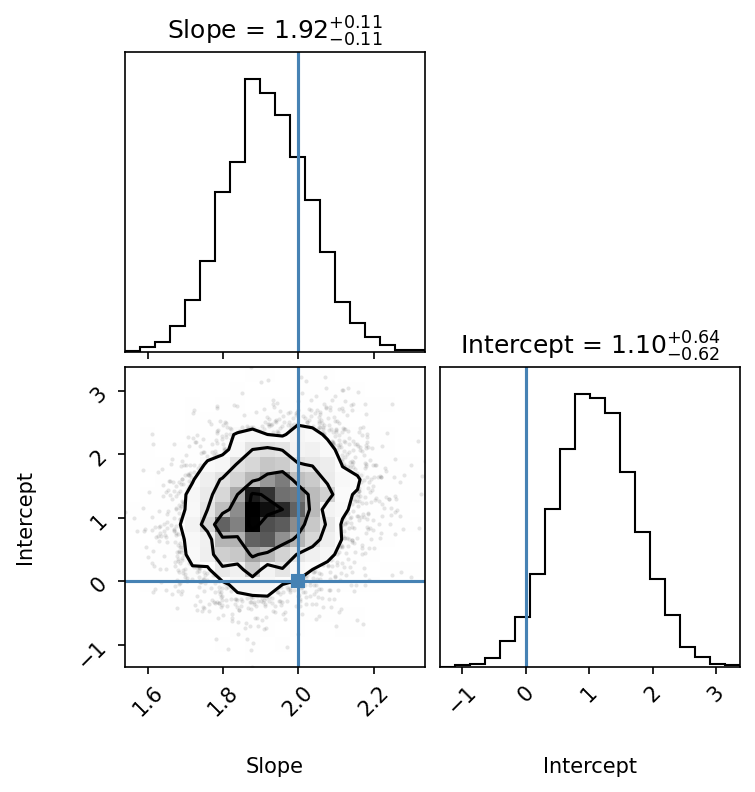

In [9]:
# Set up the data with correlated errors
np.random.seed(19)
correlation = 0.6

# Store all Monte Carlo results
n_iterations = 6000
slopes = []
intercepts = []
all_x_samples = []
all_y_samples = []

# Pre-generate all samples
for i in range(n_iterations):
    # Sample from error ellipses
    x_sample = np.zeros(N)
    y_sample = np.zeros(N)
    
    for j in range(N):
        # Individual point covariance
        point_cov = np.array([[x_err[j]**2, correlation * x_err[j] * y_err[j]],
                             [correlation * x_err[j] * y_err[j], y_err[j]**2]])
        
        # Sample from this point's error ellipse
        sample = np.random.multivariate_normal([x[j], y[j]], point_cov)
        x_sample[j] = sample[0]
        y_sample[j] = sample[1]
    
    # Fit line to this sample
    p_sample = np.polyfit(x_sample, y_sample, 1)
    slopes.append(p_sample[0])
    intercepts.append(p_sample[1])
    all_x_samples.append(x_sample.copy())
    all_y_samples.append(y_sample.copy())

corner.corner(pd.DataFrame({'slope': slopes, 'intercept': intercepts}), labels=['Slope', 'Intercept'],
              truths=[2.0, 0.0], show_titles=True);

## Monte Carlo and Apples

In [10]:
# poison the apples
mean = 100
std = 40

variance = std**2
s = np.sqrt(np.log(1 + variance/mean**2))
scale = mean / np.exp(s**2 / 2)

poison_conc = stats.lognorm(s=s, scale=scale)

lethal_limit = 250

# consume the apples
apple_consumption = stats.truncnorm(a=-2, b=np.inf, loc=1, scale=0.5)

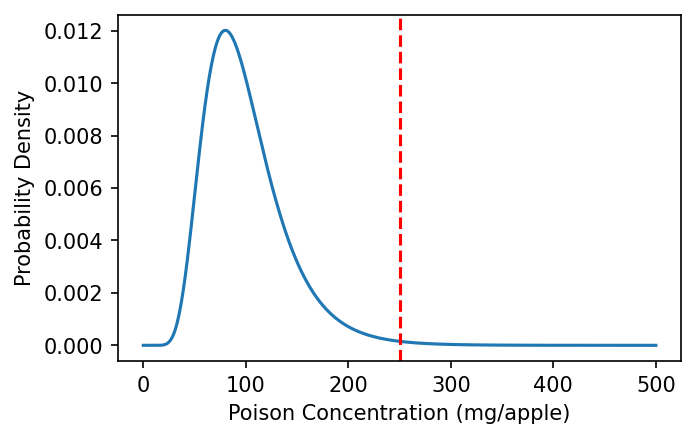

In [11]:
conc = np.linspace(0, 500, 500)
plt.plot(conc, poison_conc.pdf(conc))
plt.xlabel('Poison Concentration (mg/apple)')
plt.ylabel('Probability Density')

plt.axvline(lethal_limit, color='red', linestyle='--', label='Lethal Limit (250 mg/apple)')

Text(0, 0.5, 'Probability Density')

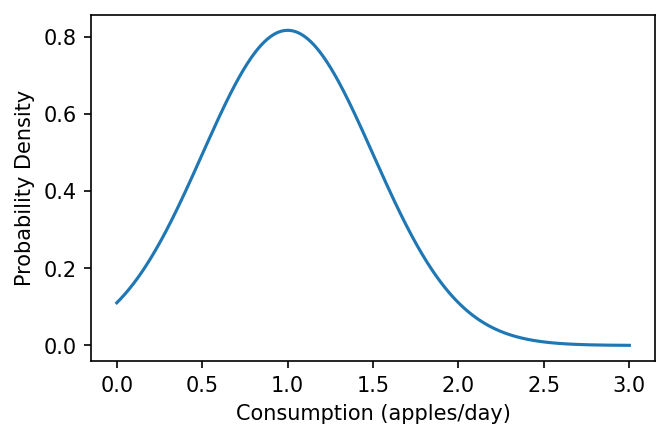

In [12]:
consumed = np.linspace(0, 3, 500)
plt.plot(consumed, apple_consumption.pdf(consumed), label='Apple Consumption')
plt.xlabel('Consumption (apples/day)')
plt.ylabel('Probability Density')

np.float64(3.51)

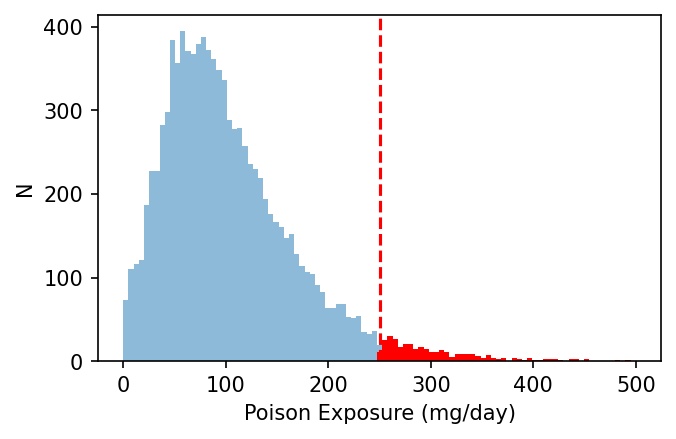

In [15]:
N = 10000
exposure = poison_conc.rvs(N) * apple_consumption.rvs(N)

bins = np.linspace(0,500,100)

plt.hist(exposure, bins=bins, alpha=0.5, label='Exposure Distribution')

plt.hist(exposure[exposure > lethal_limit], bins=bins, color='red',  label='Exposure Distribution')

plt.axvline(lethal_limit, color='red', linestyle='--', label='Lethal Limit (250 mg/apple)')

plt.xlabel('Poison Exposure (mg/day)')
plt.ylabel('N')

100 * (exposure > lethal_limit).sum() / exposure.size